# ใบงานที่ 7: Convolutional Neural Network และการประยุกต์ใช้งาน
**LAB: CNN on a Dataset of Your Choice** — ชุดข้อมูล: *Fake Bills* (แยกธนบัตรจริง/ปลอมจากขนาดทางกายภาพ 6 ค่า)

**ขั้นตอน**
1. โหลดข้อมูล + สำรวจข้อมูล
2. แบ่งข้อมูล Train / Validation / Test
3. จัดการ missing value และ Standardize (fit เฉพาะ train เพื่อไม่ให้เกิด data leakage)
4. สร้างโมเดล CNN (1D-CNN)
5. เปรียบเทียบจำนวน Epochs
6. เปรียบเทียบ CNN configuration (จำนวนชั้น Conv, จำนวน filter/neuron)
7. ประเมินผลด้วย Accuracy, ดูกราฟ Accuracy/Loss, ทำนายผล

In [1]:
import os, random, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)
set_seed(SEED)
print('TensorFlow', tf.__version__)

I0000 00:00:1789960542.244150   23482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1789960544.574051   23482 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. โหลดข้อมูลและสำรวจข้อมูล

In [2]:
df = pd.read_csv('data/fake_bills.csv', sep=';')
print('shape:', df.shape)
display(df.head())
print('\nMissing values:'); print(df.isna().sum())
print('\nClass distribution:'); print(df['is_genuine'].value_counts())
display(df.describe().T)

shape: (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54



Missing values:
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Class distribution:
is_genuine
True     1000
False     500
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44


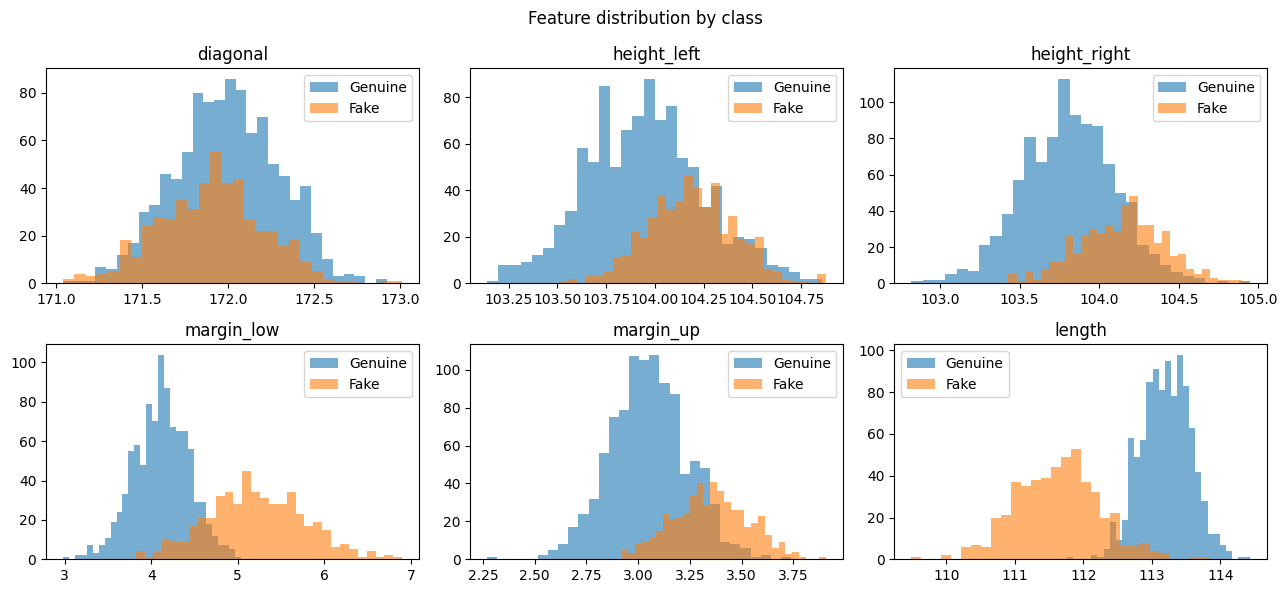

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), df.columns[1:]):
    for label, name in [(True, 'Genuine'), (False, 'Fake')]:
        ax.hist(df.loc[df.is_genuine == label, col].dropna(), bins=30, alpha=.6, label=name)
    ax.set_title(col); ax.legend()
plt.suptitle('Feature distribution by class'); plt.tight_layout(); plt.show()

**ข้อสังเกต:** ข้อมูลมี 1,500 แถว, 6 features (ค่าตัวเลขทั้งหมด), มี missing เฉพาะ `margin_low`, และคลาสไม่สมดุล (จริง 1,000 : ปลอม 500 ≈ 2:1) → ใช้ `stratify` ตอนแบ่งข้อมูล

## 2. แบ่งข้อมูล Train / Validation / Test

In [4]:
X = df.drop(columns='is_genuine').values.astype('float32')
y = df['is_genuine'].astype(int).values   # 1 = genuine, 0 = fake

X_tr_full, X_test, y_tr_full, y_test, idx_tr_full, idx_test = train_test_split(
    X, y, np.arange(len(df)), test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.20, stratify=y_tr_full, random_state=SEED)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print('genuine ratio  train/val/test:', y_train.mean().round(3), y_val.mean().round(3), y_test.mean().round(3))

Train: (960, 6)  Val: (240, 6)  Test: (300, 6)
genuine ratio  train/val/test: 0.667 0.667 0.667


## 3. Impute missing value + Standardize
fit `SimpleImputer(median)` และ `StandardScaler` เฉพาะ **train** แล้วนำไป transform val/test

In [5]:
imputer = SimpleImputer(strategy='median').fit(X_train)
scaler = StandardScaler().fit(imputer.transform(X_train))
prep = lambda a: scaler.transform(imputer.transform(a)).astype('float32')

X_train_s, X_val_s, X_test_s = prep(X_train), prep(X_val), prep(X_test)

# CNN (Conv1D) ต้องการ input shape = (samples, steps, channels) -> มอง 6 features เป็นลำดับความยาว 6, 1 channel
X_train_c = X_train_s[..., None]; X_val_c = X_val_s[..., None]; X_test_c = X_test_s[..., None]
print('input shape:', X_train_c.shape)
print('train mean≈', X_train_s.mean().round(3), ' std≈', X_train_s.std().round(3))

input shape: (960, 6, 1)
train mean≈ 0.0  std≈ 1.0


## 4. สร้างโมเดล CNN
ข้อมูลเป็นตาราง (6 ค่า) ไม่ใช่รูปภาพ จึงใช้ **1D-CNN**: ให้ตัวกรอง (kernel) เลื่อนผ่านลำดับ feature เพื่อเรียนรู้ pattern ระหว่าง feature ที่อยู่ติดกัน  
ฟังก์ชัน `build_cnn` ปรับได้ทั้ง **จำนวนชั้น Conv**, **จำนวน filter** และ **จำนวน neuron ใน Dense layer**

In [6]:
def build_cnn(n_conv=2, filters=32, dense_units=64, kernel_size=3, input_len=6, dropout=0.2):
    model = keras.Sequential([layers.Input(shape=(input_len, 1))])
    length = input_len
    for i in range(n_conv):
        f = filters * (2 ** i)                       # เพิ่ม filter เป็น 2 เท่าในแต่ละชั้น
        model.add(layers.Conv1D(f, kernel_size, padding='same', activation='relu'))
        if length >= 2:                              # pool เฉพาะเมื่อความยาวยังพอ
            model.add(layers.MaxPooling1D(2)); length //= 2
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))  # binary classification
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
BATCH = 64
def train_eval(epochs, seed=SEED, **cfg):
    """train 1 โมเดล -> (model, history, val_acc, test_acc)"""
    keras.backend.clear_session(); set_seed(seed)
    m = build_cnn(**cfg)
    h = m.fit(X_train_c, y_train, validation_data=(X_val_c, y_val),
              epochs=epochs, batch_size=BATCH, verbose=0)
    test_acc = accuracy_score(y_test, (m.predict(X_test_c, verbose=0).ravel() > .5).astype(int))
    return m, h, h.history['val_accuracy'][-1], test_acc

SEEDS = [42, 7, 2026]   # รันซ้ำหลาย seed เพื่อให้ผลเปรียบเทียบน่าเชื่อถือขึ้น (test set มีแค่ 300 แถว)

## 5. เปรียบเทียบจำนวน Epochs
ใช้โครงสร้างเดียวกัน (2 Conv, 32 filters, Dense 64) เทรนใหม่ทุกครั้งด้วย epochs = 5, 10, 20, 50, 100

In [8]:
EPOCH_LIST = [5, 10, 20, 50, 100]
base_cfg = dict(n_conv=2, filters=32, dense_units=64)
rows, epoch_hist = [], {}
for ep in EPOCH_LIST:
    tr, va, te = [], [], []
    for s in SEEDS:
        m, h, v, t = train_eval(ep, seed=s, **base_cfg)
        tr.append(h.history['accuracy'][-1]); va.append(v); te.append(t)
        if s == SEEDS[0]: epoch_hist[ep] = h.history
    rows.append(dict(epochs=ep, train_acc=np.mean(tr), val_acc=np.mean(va),
                     test_acc=np.mean(te), test_acc_std=np.std(te)))
    print(f'epochs={ep:>3}  train={np.mean(tr):.4f}  val={np.mean(va):.4f}  test={np.mean(te):.4f} ± {np.std(te):.4f}')
epoch_df = pd.DataFrame(rows).round(4)
display(epoch_df)

epochs=  5  train=0.9854  val=0.9750  test=0.9744 ± 0.0016


epochs= 10  train=0.9937  val=0.9806  test=0.9833 ± 0.0000


epochs= 20  train=0.9948  val=0.9833  test=0.9867 ± 0.0000


epochs= 50  train=0.9972  val=0.9833  test=0.9767 ± 0.0047


epochs=100  train=1.0000  val=0.9833  test=0.9722 ± 0.0016


,epochs,train_acc,val_acc,test_acc,test_acc_std
0,5,0.9854,0.9750,0.9744,0.0016
1,10,0.9937,0.9806,0.9833,0.0000
2,20,0.9948,0.9833,0.9867,0.0000
3,50,0.9972,0.9833,0.9767,0.0047
4,100,1.0000,0.9833,0.9722,0.0016


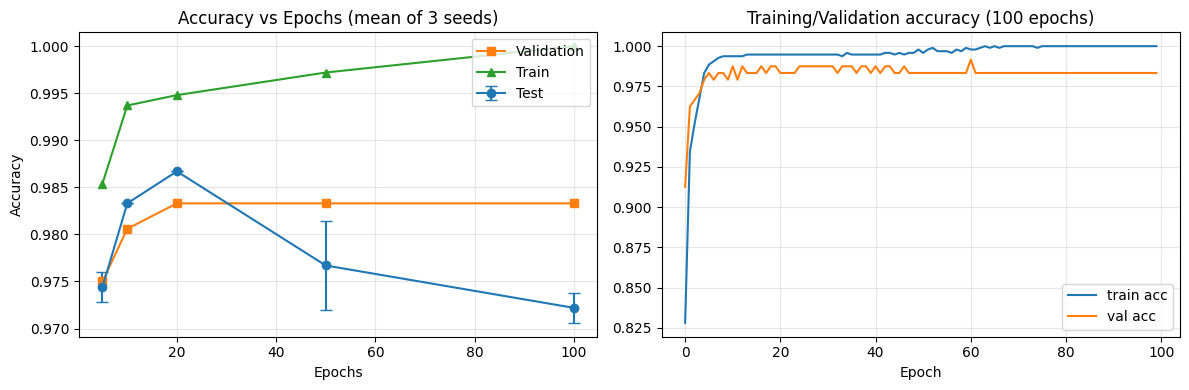

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].errorbar(epoch_df.epochs, epoch_df.test_acc, yerr=epoch_df.test_acc_std, marker='o', capsize=4, label='Test')
ax[0].plot(epoch_df.epochs, epoch_df.val_acc, marker='s', label='Validation')
ax[0].plot(epoch_df.epochs, epoch_df.train_acc, marker='^', label='Train')
ax[0].set_xlabel('Epochs'); ax[0].set_ylabel('Accuracy'); ax[0].set_title('Accuracy vs Epochs (mean of 3 seeds)'); ax[0].legend(); ax[0].grid(alpha=.3)

h = epoch_hist[100]
ax[1].plot(h['accuracy'], label='train acc'); ax[1].plot(h['val_accuracy'], label='val acc')
ax[1].set_title('Training/Validation accuracy (100 epochs)'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. เปรียบเทียบ CNN Configuration
ทุก configuration เทรน 50 epochs (รัน 3 seeds แล้วเฉลี่ย)

In [10]:
CONFIGS = {
    'A: 1 Conv(16) + Dense16'        : dict(n_conv=1, filters=16, dense_units=16),
    'B: 1 Conv(32) + Dense64'        : dict(n_conv=1, filters=32, dense_units=64),
    'C: 2 Conv(32-64) + Dense32'     : dict(n_conv=2, filters=32, dense_units=32),
    'D: 2 Conv(32-64) + Dense128'    : dict(n_conv=2, filters=32, dense_units=128),
    'E: 3 Conv(16-32-64) + Dense64'  : dict(n_conv=3, filters=16, dense_units=64),
    'F: 3 Conv(32-64-128) + Dense128': dict(n_conv=3, filters=32, dense_units=128),
}
EPOCHS_CFG = 50
rows, cfg_hist, cfg_models = [], {}, {}
for name, cfg in CONFIGS.items():
    tr, va, te = [], [], []
    for s in SEEDS:
        m, h, v, t = train_eval(EPOCHS_CFG, seed=s, **cfg)
        tr.append(h.history['accuracy'][-1]); va.append(v); te.append(t)
        if s == SEEDS[0]: cfg_hist[name] = h.history; cfg_models[name] = m
    params = cfg_models[name].count_params()
    rows.append(dict(config=name, conv_layers=cfg['n_conv'], filters=cfg['filters'], dense_units=cfg['dense_units'],
                     params=params, train_acc=np.mean(tr), val_acc=np.mean(va),
                     test_acc=np.mean(te), test_acc_std=np.std(te)))
    print(f'{name:<34} params={params:>7}  val={np.mean(va):.4f}  test={np.mean(te):.4f} ± {np.std(te):.4f}')
cfg_df = pd.DataFrame(rows).round(4)
display(cfg_df)

A: 1 Conv(16) + Dense16            params=    865  val=0.9792  test=0.9867 ± 0.0027


B: 1 Conv(32) + Dense64            params=   6401  val=0.9792  test=0.9844 ± 0.0016


C: 2 Conv(32-64) + Dense32         params=   8449  val=0.9833  test=0.9833 ± 0.0027


D: 2 Conv(32-64) + Dense128        params=  14785  val=0.9833  test=0.9789 ± 0.0042


E: 3 Conv(16-32-64) + Dense64      params=  12065  val=0.9861  test=0.9778 ± 0.0042


F: 3 Conv(32-64-128) + Dense128    params=  47681  val=0.9833  test=0.9789 ± 0.0031


,config,conv_layers,filters,dense_units,params,train_acc,val_acc,test_acc,test_acc_std
0,A: 1 Conv(16) + Dense16,1,16,16,865,0.9931,0.9792,0.9867,0.0027
1,B: 1 Conv(32) + Dense64,1,32,64,6401,0.9948,0.9792,0.9844,0.0016
2,C: 2 Conv(32-64) + Dense32,2,32,32,8449,0.9958,0.9833,0.9833,0.0027
3,D: 2 Conv(32-64) + Dense128,2,32,128,14785,0.9983,0.9833,0.9789,0.0042
4,E: 3 Conv(16-32-64) + Dense64,3,16,64,12065,0.9976,0.9861,0.9778,0.0042
5,F: 3 Conv(32-64-128) + Dense128,3,32,128,47681,1.0000,0.9833,0.9789,0.0031


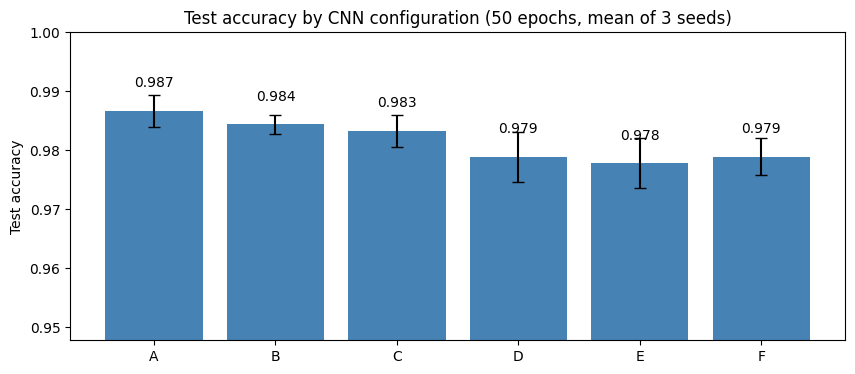

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
short = [c.split(':')[0] for c in cfg_df.config]
ax.bar(short, cfg_df.test_acc, yerr=cfg_df.test_acc_std, capsize=4, color='steelblue')
ax.set_ylim(cfg_df.test_acc.min() - .03, 1.0); ax.set_ylabel('Test accuracy')
ax.set_title(f'Test accuracy by CNN configuration ({EPOCHS_CFG} epochs, mean of 3 seeds)')
for i, v in enumerate(cfg_df.test_acc): ax.text(i, v + .004, f'{v:.3f}', ha='center')
plt.show()

### กราฟ Training / Validation Accuracy และ Loss ของแต่ละ configuration

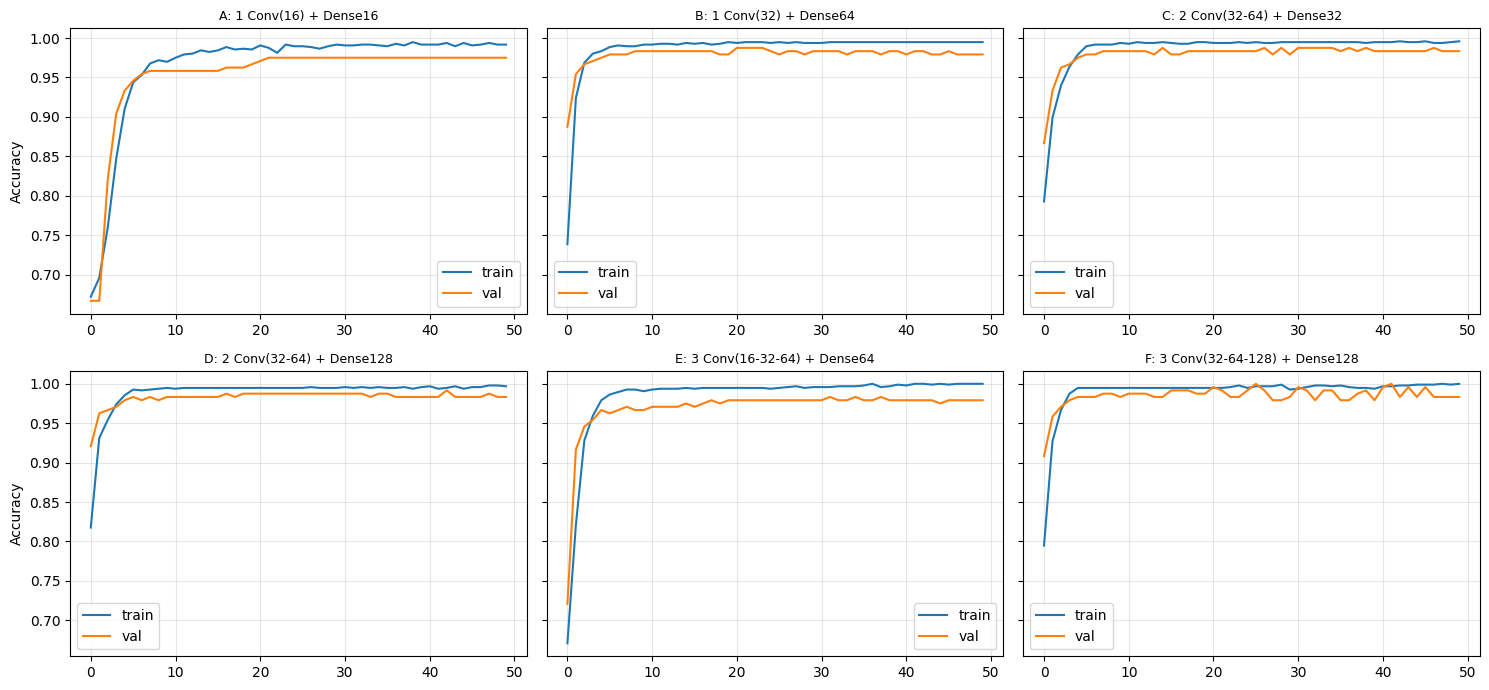

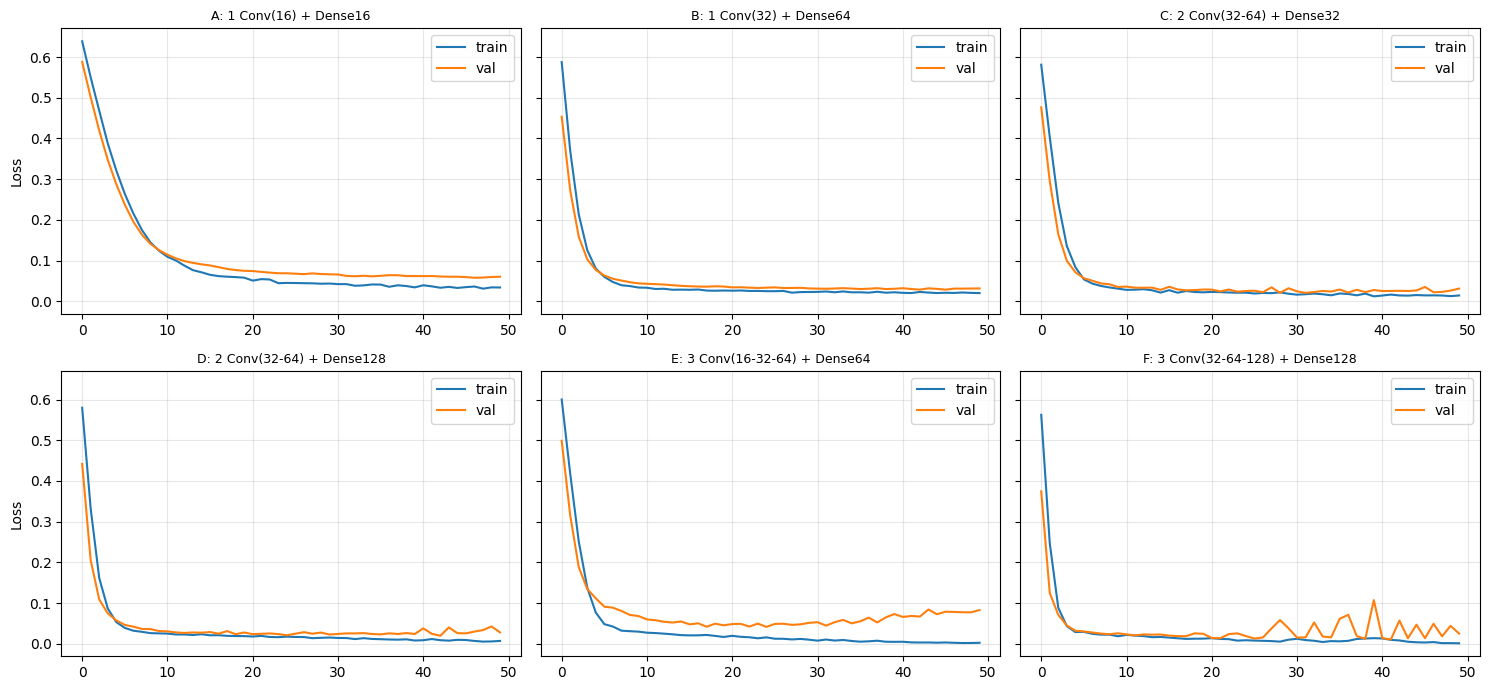

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey='row')
for ax, (name, h) in zip(axes[0], list(cfg_hist.items())[:3]):
    ax.plot(h['accuracy'], label='train'); ax.plot(h['val_accuracy'], label='val'); ax.set_title(name, fontsize=9); ax.legend(); ax.grid(alpha=.3)
for ax, (name, h) in zip(axes[1], list(cfg_hist.items())[3:]):
    ax.plot(h['accuracy'], label='train'); ax.plot(h['val_accuracy'], label='val'); ax.set_title(name, fontsize=9); ax.legend(); ax.grid(alpha=.3)
axes[0][0].set_ylabel('Accuracy'); axes[1][0].set_ylabel('Accuracy'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, (name, h) in zip(axes.ravel(), cfg_hist.items()):
    ax.plot(h['loss'], label='train'); ax.plot(h['val_loss'], label='val'); ax.set_title(name, fontsize=9); ax.legend(); ax.grid(alpha=.3)
axes[0][0].set_ylabel('Loss'); axes[1][0].set_ylabel('Loss'); plt.tight_layout(); plt.show()

## 7. เลือกโมเดลที่ดีที่สุดและประเมินผลบน Test set

Best config (by validation accuracy): E: 3 Conv(16-32-64) + Dense64
Test accuracy: 0.9767
              precision    recall  f1-score   support

        Fake       0.96      0.97      0.97       100
     Genuine       0.98      0.98      0.98       200

    accuracy                           0.98       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.98      0.98      0.98       300



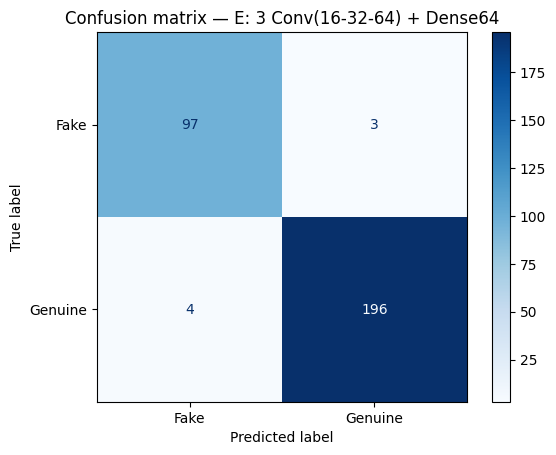

In [13]:
best_name = cfg_df.sort_values(['val_acc', 'test_acc'], ascending=False).iloc[0].config   # เลือกจาก validation ไม่ใช่ test
best_model = cfg_models[best_name]
print('Best config (by validation accuracy):', best_name)

proba = best_model.predict(X_test_c, verbose=0).ravel()
pred = (proba > .5).astype(int)
print('Test accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, target_names=['Fake', 'Genuine']))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['Fake', 'Genuine']).plot(cmap='Blues')
plt.title(f'Confusion matrix — {best_name}'); plt.show()

## 8. ทำนายผลบนชุดข้อมูล (Predictions)
บันทึกผลทำนายของชุด Test (300 แถว) และทำนายทั้งชุดข้อมูล (1,500 แถว) พร้อมระบุว่าแถวไหนเป็น train/val/test

In [14]:
# Test-set predictions
feat_cols = list(df.columns[1:])
pred_df = df.iloc[idx_test].copy().reset_index().rename(columns={'index': 'row_id'})
pred_df['actual'] = np.where(y_test == 1, 'Genuine', 'Fake')
pred_df['predicted'] = np.where(pred == 1, 'Genuine', 'Fake')
pred_df['prob_genuine'] = proba.round(4)
pred_df['correct'] = pred_df.actual == pred_df.predicted
pred_df = pred_df[['row_id'] + feat_cols + ['actual', 'predicted', 'prob_genuine', 'correct']]
pred_df.to_csv('predictions_test.csv', index=False)

# Full-dataset predictions
proba_all = best_model.predict(prep(X)[..., None], verbose=0).ravel()
all_df = df.copy(); all_df.insert(0, 'row_id', np.arange(len(df)))
all_df['split'] = np.where(np.isin(np.arange(len(df)), idx_test), 'test', 'train/val')
all_df['actual'] = np.where(y == 1, 'Genuine', 'Fake')
all_df['predicted'] = np.where(proba_all > .5, 'Genuine', 'Fake')
all_df['prob_genuine'] = proba_all.round(4)
all_df['correct'] = all_df.actual == all_df.predicted
all_df.drop(columns='is_genuine').to_csv('predictions_all.csv', index=False)

print(f'Test accuracy: {pred_df.correct.mean():.4f}   |   Whole dataset accuracy: {all_df.correct.mean():.4f} (รวมข้อมูลที่โมเดลเคยเห็นตอนเทรน)')
display(pred_df.head(10))
print('\nตัวอย่างที่ทำนายผิด:'); display(pred_df[~pred_df.correct].head(10))

Test accuracy: 0.9767   |   Whole dataset accuracy: 0.9920 (รวมข้อมูลที่โมเดลเคยเห็นตอนเทรน)


,row_id,diagonal,height_left,height_right,margin_low,margin_up,length,actual,predicted,prob_genuine,correct
0,803,171.87,103.27,104.50,3.85,3.03,113.19,Genuine,Genuine,1.0000,True
1,1306,172.13,103.99,104.06,5.80,3.28,111.30,Fake,Fake,0.0000,True
2,1263,171.59,104.05,104.40,5.05,3.45,111.14,Fake,Fake,0.0000,True
3,38,172.00,103.76,104.27,4.42,3.29,112.67,Genuine,Genuine,0.8372,True
4,257,172.19,104.03,104.25,4.17,2.81,112.94,Genuine,Genuine,0.9999,True
5,395,171.82,104.33,103.83,3.92,2.73,112.99,Genuine,Genuine,1.0000,True
6,834,172.07,103.61,104.34,4.34,2.85,113.03,Genuine,Genuine,1.0000,True
7,606,171.52,104.52,103.96,3.43,3.01,113.44,Genuine,Genuine,1.0000,True
8,397,172.15,104.18,103.53,3.92,3.30,113.42,Genuine,Genuine,1.0000,True
9,11,171.84,104.59,104.00,3.88,3.27,113.08,Genuine,Genuine,1.0000,True



ตัวอย่างที่ทำนายผิด:


,row_id,diagonal,height_left,height_right,margin_low,margin_up,length,actual,predicted,prob_genuine,correct
24,1121,171.40,104.38,104.19,NaN,3.17,112.39,Fake,Genuine,0.9988,False
55,341,171.90,104.21,104.21,4.77,3.38,113.20,Genuine,Fake,0.0093,False
65,728,171.94,104.11,104.16,4.08,3.35,111.76,Genuine,Fake,0.0003,False
108,1252,172.03,104.60,104.00,4.36,3.26,112.08,Fake,Genuine,0.7436,False
165,75,172.26,103.85,103.70,4.16,3.20,112.35,Genuine,Fake,0.2483,False
206,1160,172.39,104.05,104.32,4.13,3.41,112.66,Fake,Genuine,0.9860,False
277,214,172.10,103.61,103.79,4.86,3.14,112.89,Genuine,Fake,0.4004,False


## 9. สรุปผล

In [15]:
print('=== Accuracy vs Epochs (base config: 2 Conv, Dense 64) ===')
display(epoch_df[['epochs', 'train_acc', 'val_acc', 'test_acc', 'test_acc_std']])
print('=== Accuracy by CNN configuration (50 epochs) ===')
display(cfg_df[['config', 'params', 'train_acc', 'val_acc', 'test_acc', 'test_acc_std']])
epoch_df.to_csv('results_epochs.csv', index=False); cfg_df.to_csv('results_configs.csv', index=False)

=== Accuracy vs Epochs (base config: 2 Conv, Dense 64) ===


,epochs,train_acc,val_acc,test_acc,test_acc_std
0,5,0.9854,0.9750,0.9744,0.0016
1,10,0.9937,0.9806,0.9833,0.0000
2,20,0.9948,0.9833,0.9867,0.0000
3,50,0.9972,0.9833,0.9767,0.0047
4,100,1.0000,0.9833,0.9722,0.0016


=== Accuracy by CNN configuration (50 epochs) ===


,config,params,train_acc,val_acc,test_acc,test_acc_std
0,A: 1 Conv(16) + Dense16,865,0.9931,0.9792,0.9867,0.0027
1,B: 1 Conv(32) + Dense64,6401,0.9948,0.9792,0.9844,0.0016
2,C: 2 Conv(32-64) + Dense32,8449,0.9958,0.9833,0.9833,0.0027
3,D: 2 Conv(32-64) + Dense128,14785,0.9983,0.9833,0.9789,0.0042
4,E: 3 Conv(16-32-64) + Dense64,12065,0.9976,0.9861,0.9778,0.0042
5,F: 3 Conv(32-64-128) + Dense128,47681,1.0000,0.9833,0.9789,0.0031


### ผลการทดลอง

**1) จำนวน Epochs** (2 Conv + Dense 64, เฉลี่ย 3 seeds)

| Epochs | Train | Val | Test |
|---|---|---|---|
| 5 | 98.5% | 97.5% | 97.4% |
| 10 | 99.4% | 98.1% | 98.3% |
| **20** | 99.5% | 98.3% | **98.7%** |
| 50 | 99.7% | 98.3% | 97.7% |
| 100 | 100% | 98.3% | 97.2% |

- 5 epochs ยังเรียนรู้ไม่เต็มที่ (underfit เล็กน้อย) → Test accuracy ดีที่สุดที่ประมาณ **20 epochs**
- หลังจากนั้น Train accuracy ขึ้นไปถึง 100% แต่ Validation คงที่ และ Test accuracy ลดลง → เริ่ม **overfit** (จำข้อมูลเทรน)

**2) CNN Configuration** (50 epochs, เฉลี่ย 3 seeds)

| Config | Params | Val | Test |
|---|---|---|---|
| A: 1 Conv(16) + Dense16 | 865 | 97.9% | 98.7% |
| B: 1 Conv(32) + Dense64 | 6,401 | 97.9% | 98.4% |
| C: 2 Conv(32-64) + Dense32 | 8,449 | 98.3% | 98.3% |
| D: 2 Conv(32-64) + Dense128 | 14,785 | 98.3% | 97.9% |
| E: 3 Conv(16-32-64) + Dense64 | 12,065 | 98.6% | 97.8% |
| F: 3 Conv(32-64-128) + Dense128 | 47,681 | 98.3% | 97.9% |

- ทุก configuration ได้ Accuracy อยู่ในช่วง ~97.8–98.7% ต่างกันไม่เกิน 1% (≈ 3 แถวจาก test 300 แถว) ซึ่งอยู่ในระดับความคลาดเคลื่อนของการสุ่ม จึงสรุปไม่ได้ว่าโมเดลใหญ่กว่าดีกว่า
- โมเดลเล็กสุด (A, 865 พารามิเตอร์) ให้ผลเท่ากับหรือดีกว่าโมเดลใหญ่ เพราะข้อมูลมีเพียง 6 features และแยกคลาสได้ง่าย การเพิ่มชั้น/นิวรอนมากขึ้นจึงเพิ่มแค่ความเสี่ยง overfit (Train → 100% ใน config F)
- เลือกโมเดลจาก **Validation accuracy** (ไม่ใช้ test เลือก) ได้ config E → Test accuracy **97.67%** (Fake recall 0.97, Genuine recall 0.98)

**ข้อสังเกต:** ลำดับของ 6 features ในตารางไม่มีความหมายเชิงตำแหน่งเหมือนพิกเซลในรูปภาพ ข้อได้เปรียบของ CNN (local pattern) จึงไม่ชัดเจนในข้อมูลชนิดนี้ — ผลที่ได้ใกล้เคียงกับ MLP ในใบงานที่ 6 CNN เหมาะกับข้อมูลรูปภาพ/สัญญาณ/อนุกรมเวลามากกว่า